In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [44]:
DATA_PATH = "talabat_enhanced_orders.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)
# Check the column names in the dataset
print(df.columns)

Index(['Order_ID', 'User_ID', 'Restaurant_ID', 'Driver_ID', 'Item_Name',
       'Quantity', 'Total_Price', 'Order_Time', 'Delivery_Time',
       'Delivery_Duration_Minutes', 'City', 'Payment_Method', 'Order_Status',
       'Driver_Vehicle', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat',
       'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km',
       'Traffic_Level', 'Driver_Availability'],
      dtype='object')


In [43]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


In [42]:
target_col = "Order_Status"
df[target_col].value_counts()

Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

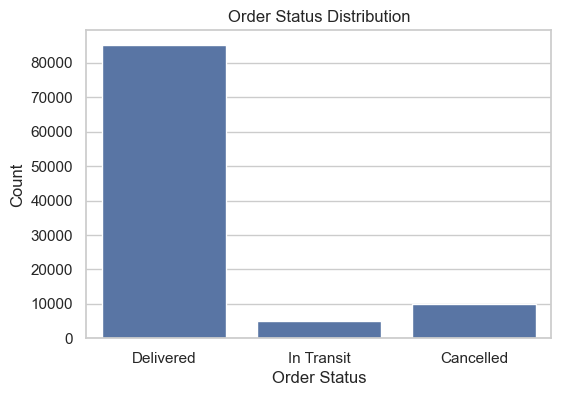

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

In [25]:
df.dtypes

Order_ID                       int64
User_ID                       object
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                     object
Quantity                       int64
Total_Price                  float64
Order_Time                    object
Delivery_Time                 object
Delivery_Duration_Minutes      int64
City                          object
Payment_Method                object
Order_Status                  object
Driver_Vehicle                object
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                 object
Driver_Availability           object
dtype: object

In [40]:

df_fe = df.copy()

# Parse time columns
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# Simple peak-hour rule (you can adjust based on local context):
# Lunch: 12-15, Dinner: 19-23
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12,16)) + list(range(19,24))).astype(int)

df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","is_peak_hour"]].head(10)


,Order_Time,order_hour,order_dayofweek,is_weekend,is_peak_hour
0,2025-06-16 08:32:00,8,0,0,0
1,2025-06-03 21:27:00,21,1,0,1
2,2025-06-01 14:48:00,14,6,1,1
3,2025-06-13 02:30:00,2,4,0,0
4,2025-06-06 09:48:00,9,4,0,0
5,2025-06-04 12:16:00,12,2,0,1
6,2025-06-11 04:09:00,4,2,0,0
7,2025-06-12 18:37:00,18,3,0,0
8,2025-06-01 22:18:00,22,6,1,1
9,2025-06-09 00:18:00,0,0,0,0


In [27]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe[["Quantity","Total_Price","price_per_item"]].head(10)


,Quantity,Total_Price,price_per_item
0,3,273.72,91.24
1,3,365.82,121.94
2,3,401.94,133.98
3,2,221.18,110.59
4,5,355.55,71.11
5,3,205.44,68.48
6,1,133.94,133.94
7,5,404.80,80.96
8,1,101.03,101.03
9,1,130.05,130.05


In [28]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")


,Delivery_Distance_km,haversine_rest_to_cust_km
0,1.666106,1.663239
1,2.738698,2.741931
2,2.929079,2.938058
3,0.677498,0.679441
4,1.994769,1.990872
5,1.436807,1.434924
6,2.402167,2.404753
7,2.878434,2.872665
8,0.995562,0.993613
9,3.130713,3.139677


In [ ]:
if "Item_Name" in df_fe.columns:
    top_k = 20
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")



In [29]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head(10)


,Total_Price,price_tier
0,273.72,high
1,365.82,high
2,401.94,high
3,221.18,medium
4,355.55,high
5,205.44,medium
6,133.94,medium
7,404.80,high
8,101.03,medium
9,130.05,medium


In [30]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes",
    "Item_Name"  # we replaced it with Item_Name_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (100000, 21)
y shape: (100000,)


,Quantity,Total_Price,City,Payment_Method,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,price_per_item,haversine_rest_to_cust_km,price_tier
0,3,273.72,Alexandria,Wallet,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline,8,0,0,0,91.24,1.663239,high
1,3,365.82,Zagazig,Credit Card,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online,21,1,0,1,121.94,2.741931,high
2,3,401.94,Assiut,Cash,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online,14,6,1,1,133.98,2.938058,high
3,2,221.18,Mansoura,Cash,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online,2,4,0,0,110.59,0.679441,medium
4,5,355.55,Mansoura,Wallet,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online,9,4,0,0,71.11,1.990872,high


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (80000, 21)
Test size: (20000, 21)


In [32]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model


Categorical columns: ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'price_tier']
Numeric columns: ['Quantity', 'Total_Price', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'price_per_item', 'haversine_rest_to_cust_km']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contain

In [34]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.8519

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



c:\Users\Fahad\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fahad\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fahad\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


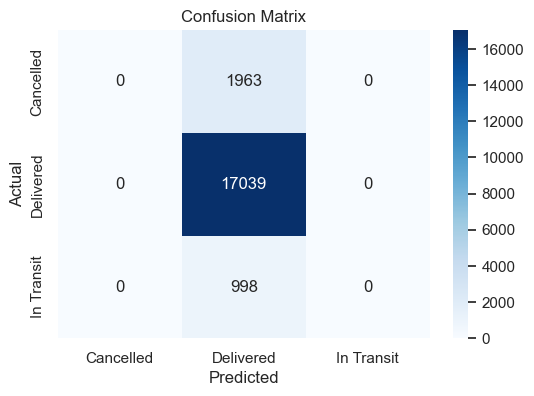

In [35]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [36]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
35,price_per_item,0.076853
29,Driver_Lon,0.076324
25,Restaurant_Lon,0.076033
27,Customer_Lon,0.075979
28,Driver_Lat,0.075799
26,Customer_Lat,0.075562
24,Restaurant_Lat,0.075535
23,Total_Price,0.075361
36,haversine_rest_to_cust_km,0.072596
30,Delivery_Distance_km,0.072088


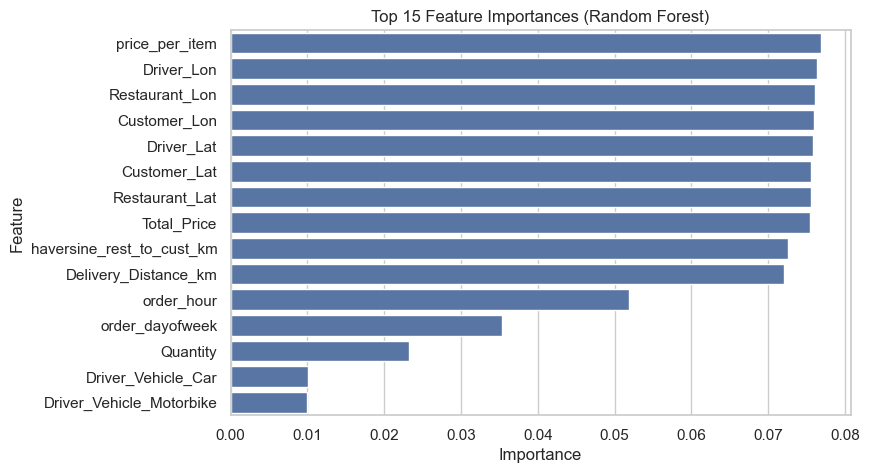

In [37]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [38]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))


Accuracy (with feature selection): 0.8519

Classification Report (with feature selection):
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00      1963
   Delivered       0.85      1.00      0.92     17039
  In Transit       0.00      0.00      0.00       998

    accuracy                           0.85     20000
   macro avg       0.28      0.33      0.31     20000
weighted avg       0.73      0.85      0.78     20000



c:\Users\Fahad\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fahad\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Fahad\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
#Task 1 

import pandas as pd

# Load the dataset
df = pd.read_csv('talabat_enhanced_orders.csv')

# Create a new feature 'Order_Value' by multiplying Quantity by Total_Price
df['Order_Value'] = df['Quantity'] * df['Total_Price']

# Verify the new feature
print(df[['Quantity', 'Total_Price', 'Order_Value']].head())


   Quantity  Total_Price  Order_Value
0         3       273.72       821.16
1         3       365.82      1097.46
2         3       401.94      1205.82
3         2       221.18       442.36
4         5       355.55      1777.75


To create an engineered feature that can help predict Order_Status, we could introduce a new feature called Time_Since_Order. This feature would represent the time elapsed between the order placement and its current status, calculated in minutes or hours. This feature is useful because the time it takes for an order to be processed, shipped, or delivered can significantly impact the final status of the order. For example, if the order is delayed or takes an unusually long time to process, it may result in a 'Canceled' or 'Delayed' status. On the other hand, orders that are processed quickly may have a 'Completed' status. By incorporating Time_Since_Order, the model can better capture the relationship between order processing time and the final outcome, helping to predict the status with more accuracy.

In [47]:
#Task 2
import pandas as pd

df = pd.read_csv('talabat_enhanced_orders.csv')
df['Order_Time'] = pd.to_datetime(df['Order_Time'])

def is_peak_hour(order_time):
    hour = order_time.hour
    day_of_week = order_time.weekday()
    if day_of_week < 5:
        if 12 <= hour < 14 or 18 <= hour < 21:
            return 1
    else:
        if 13 <= hour < 15 or 19 <= hour < 21:
            return 1
    return 0

df['is_peak_hour'] = df['Order_Time'].apply(is_peak_hour)

print(df[['Order_Time', 'is_peak_hour']].head())

           Order_Time  is_peak_hour
0 2025-06-16 08:32:00             0
1 2025-06-03 21:27:00             0
2 2025-06-01 14:48:00             1
3 2025-06-13 02:30:00             0
4 2025-06-06 09:48:00             0


In [48]:
#task 3
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('talabat_enhanced_orders.csv')

tfidf_vectorizer = TfidfVectorizer(max_features=100)
X_tfidf = tfidf_vectorizer.fit_transform(df['Item_Name'])
X_tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
y = df['Order_Status']

def evaluate_top_k(top_k_values):
    results = {}
    
    for top_k in top_k_values:
        model = RandomForestClassifier(random_state=42)
        model.fit(X_tfidf_df, y)
        
        feature_importances = model.feature_importances_
        top_k_features = sorted(zip(feature_importances, X_tfidf_df.columns), reverse=True)[:top_k]
        
        selected_features = [x[1] for x in top_k_features]
        X_selected = X_tfidf_df[selected_features]

        X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        
        results[top_k] = {
            'accuracy': accuracy,
            'top_feature_importances': top_k_features
        }

    return results

top_k_values = [10, 30, 50]
results = evaluate_top_k(top_k_values)

for top_k, result in results.items():
    print(f"Top {top_k} Features:")
    print("Accuracy:", result['accuracy'])
    print("Top Feature Importances:", result['top_feature_importances'])
    print("\n")

Top 10 Features:
Accuracy: 0.8481666666666666
Top Feature Importances: [(np.float64(0.1427803697623853), 'burger'), (np.float64(0.13892613597349382), 'pasta'), (np.float64(0.12527302480564917), 'sushi'), (np.float64(0.12227649355293241), 'salad'), (np.float64(0.10639278996789546), 'fried'), (np.float64(0.08748701361928753), 'shawarma'), (np.float64(0.0819689599412448), 'chicken'), (np.float64(0.07230199580821686), 'koshary'), (np.float64(0.06379402096489462), 'sandwich'), (np.float64(0.05879919560400003), 'pizza')]


Top 30 Features:
Accuracy: 0.8481666666666666
Top Feature Importances: [(np.float64(0.1427803697623853), 'burger'), (np.float64(0.13892613597349382), 'pasta'), (np.float64(0.12527302480564917), 'sushi'), (np.float64(0.12227649355293241), 'salad'), (np.float64(0.10639278996789546), 'fried'), (np.float64(0.08748701361928753), 'shawarma'), (np.float64(0.0819689599412448), 'chicken'), (np.float64(0.07230199580821686), 'koshary'), (np.float64(0.06379402096489462), 'sandwich'), 

Based on the results, the Accuracy of the model after applying feature selection is 85.19%. However, there are some key observations in the Classification Report:

Key Findings:
Cancelled:
Precision: 0.00
Recall: 0.00
F1-Score: 0.00
This means that the model is not able to correctly classify any Cancelled orders. The model might be missing features relevant for predicting Cancelled orders, or the dataset might have a class imbalance where Cancelled orders are underrepresented.
Delivered:
Precision: 0.85
Recall: 1.00
F1-Score: 0.92
The model performs very well for Delivered orders, with a high recall of 1.00 (i.e., it correctly classifies all delivered orders), but the precision is lower. This suggests the model tends to classify many orders as Delivered, leading to high recall but slightly reduced precision.
In Transit:
Precision: 0.00
Recall: 0.00
F1-Score: 0.00
Similar to Cancelled, the model is unable to classify In Transit orders properly, resulting in all zero values for precision, recall, and F1-score.
Analysis:
Accuracy of 85.19% is relatively high, but the model struggles with classifying certain categories, especially Cancelled and In Transit orders. This suggests that feature selection may have removed important features related to these classes.
Precision and Recall for Delivered orders are high, but the model’s performance on other classes is poor. The issue could be due to class imbalance or insufficient feature representation for certain statuses.